In [6]:
# https://medium.com/@lei.xiaofan/quick-start-building-sentiment-analysis-models-8c1e78c30b2c
import pandas as pd
import os
from pathlib import Path
from sklearn.model_selection import train_test_split


In [7]:
inputpath = 'input'
outputpath = 'outputs'
if os.path.exists(inputpath) is False:
    os.mkdir(inputpath)
if os.path.exists(outputpath) is False:
    os.mkdir(outputpath)
    
#input file path
news_sentiment_path = Path("training_data/news_sentiment.csv")
df = pd.read_csv(news_sentiment_path, encoding="cp1252", low_memory=False,) 


colnames = ['Sentiment', 'Headline']

# print(df.head())

In [10]:
#replacing textual categories by integers
X = df.Headline.values
y = df.Sentiment.replace(4,1)

#split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

print("training size:", len(X_train))
print("testing size:", len(X_test))

training size: 3392
testing size: 1454


In [ ]:
import re
from autocorrect import Speller
spell = Speller(lang='en')
import nltk
# nltk.download('punkt')
# nltk.download('wordnet')
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
lemm = WordNetLemmatizer()

#Fixing Word Lengthening
def reduce_lengthening(text):
    pattern = re.compile(r"(.)\1{2,}")
    return pattern.sub(r"\1\1", text)

def text_preprocess(doc):
    #Lowercasing all the letters
    temp = doc.lower()
    #Removing hashtags and mentions
    temp = re.sub("@[A-Za-z0-9_]+","", temp)
    temp = re.sub("#[A-Za-z0-9_]+","", temp)
    #Removing links
    temp = re.sub(r"http\S+", "", temp)
    temp = re.sub(r"www.\S+", "", temp)
    #removing numbers
    temp = re.sub("[0-9]","", temp)
    #Removing '
    temp = re.sub("'"," ",temp)

    #Tokenization
    temp = word_tokenize(temp)
    #Fixing Word Lengthening
    temp = [reduce_lengthening(w) for w in temp]
    #spell corrector
    # temp = [spell(w) for w in temp]
    #stem
    temp = [lemm.lemmatize(w) for w in temp]
    #Removing short words
    temp = [w for w in temp if len(w)>1]
    temp = " ".join(w for w in temp)
    
    return temp

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\35387\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\35387\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [16]:
text_preprocess("Sooo happppyyy to seee youuu!!! Visit my blog at http://example.com #excited @friend")

'soo happy see you visit blog'

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=3, max_df=0.95)
Xtrain = tfidf.fit_transform(X_train_clean)
Xtest  = tfidf.transform(X_test_clean)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
pred = cat_classifier.predict(Xtest)
print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred, labels=cat_classifier.classes_))

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# preprocess the raw text 
X_train_clean = [text_preprocess(x) for x in X_train]
X_test_clean  = [text_preprocess(x) for x in X_test]

# one hot (binary) bag of words vectoriser
# binary=True gives 0/1 per word
vectorizer = CountVectorizer(binary=True)        
X_train_vec = vectorizer.fit_transform(X_train_clean)
X_test_vec  = vectorizer.transform(X_test_clean)

# quick checks
print("vocab size:", len(vectorizer.get_feature_names_out()))
print("X_train_vec shape:", X_train_vec.shape)
print("X_test_vec shape:", X_test_vec.shape)

# show the first headline vector as dense (only do for small check)
print("first headline:", X_train_clean[0])
print("first vector (nonzero indices):", X_train_vec[0].nonzero()[1])
print("first vector (as array) sample:", X_train_vec[0].toarray()[0][:50])  # first 50 features

vocab size: 6128
X_train_vec shape: (3392, 6128)
X_test_vec shape: (1454, 6128)
first headline: city welcome dart member dallas-city welcome the member dart they merge with city
first vector (nonzero indices): [ 923 5969 1294 3291 1288 5469 5490 3305 6032]
first vector (as array) sample: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.feature_extraction.text import TfidfTransformer, CountVectorizer
from sklearn.pipeline import make_pipeline
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score


pipe = make_pipeline(CountVectorizer(), TfidfTransformer())
pipe.fit(X_train_clean)

Xtrain = pipe.transform(X_train_clean)
Xtest = pipe.transform(X_test_clean)

#training
cat_classifier = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    od_type='Iter',
    od_wait=50,
    silent=True,
    erbose=100
)
cat_classifier.fit(Xtrain, y_train, eval_set=(Xtest, y_test), plot=True)

#prediction
predictions = cat_classifier.predict(Xtest)
print('Test score: %.2f\n' % (accuracy_score(y_test, predictions)))

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Test score: 0.70



Top-level keys (datasets): ['learn', 'validation']
- learn: metrics = ['MultiClass']
- validation: metrics = ['MultiClass']

Plotting metric: MultiClass for learn and validation


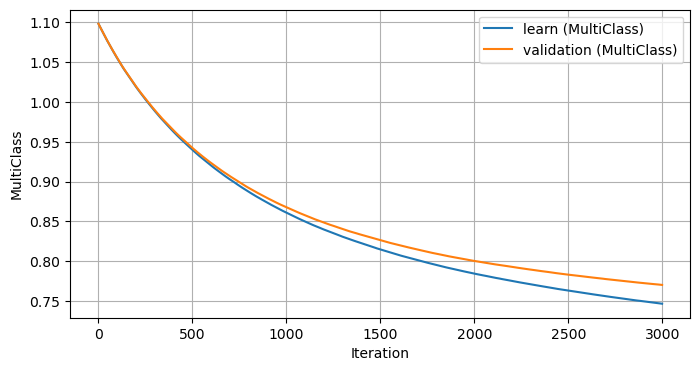

In [ ]:
import matplotlib.pyplot as plt

res = cat_classifier.get_evals_result()

# Show structure so you can see available dataset names and metric names
print("Top-level keys (datasets):", list(res.keys()))
for ds_name, metrics in res.items():
    print(f"- {ds_name}: metrics = {list(metrics.keys())}")

# Choose dataset keys
ds_keys = list(res.keys())
train_key = ds_keys[0]
val_key = ds_keys[1] if len(ds_keys) > 1 else None

# Pick the first metric reported for the train set
metric = list(res[train_key].keys())[0]
print("\nPlotting metric:", metric, "for", train_key, "and", val_key)

# Prepare series 
train_series = res[train_key][metric]
val_series = res[val_key][metric] if val_key is not None and metric in res[val_key] else None

plt.figure(figsize=(8,4))
plt.plot(train_series, label=f'{train_key} ({metric})')
if val_series is not None:
    plt.plot(val_series, label=f'{val_key} ({metric})')
plt.xlabel('Iteration')
plt.ylabel(metric)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

LABEL_MAP = {-1: "negative", 1: "positive", 0: "neutral"}
NAME_TO_ID = {v: k for k, v in LABEL_MAP.items()}

def predict_text_single(text):
    cleaned = text_preprocess(text)
    X = pipe.transform([cleaned])
    pred_raw = cat_classifier.predict(X)[0]
    val = np.asarray(pred_raw).ravel()[0]
    if isinstance(val, bytes):
        val = val.decode()
    if isinstance(val, str):
        label_id = NAME_TO_ID[val]
    else:
        label_id = int(val)
    proba = cat_classifier.predict_proba(X)[0].tolist()
    return {"text": text, "cleaned": cleaned, "label_id": label_id, "label": LABEL_MAP[label_id], "proba": proba}

def predict_texts_batch(texts):
    cleaned = [text_preprocess(t) for t in texts]
    X = pipe.transform(cleaned)
    preds = cat_classifier.predict(X)
    probas = cat_classifier.predict_proba(X)
    results = []
    for i, t in enumerate(texts):
        pred_raw = preds[i]
        val = np.asarray(pred_raw).ravel()[0]
        if isinstance(val, bytes):
            val = val.decode()
        if isinstance(val, str):
            label_id = NAME_TO_ID[val]
        else:
            label_id = int(val)
        results.append({
            "text": t,
            "cleaned": cleaned[i],
            "label_id": label_id,
            "label": LABEL_MAP[label_id],
            "proba": probas[i].tolist()
        })
    return results

In [41]:
result = predict_text_single("Stocks are looking good today!")
print(result)

{'text': 'Stocks are looking good today!', 'cleaned': 'stock are looking good today', 'label_id': 0, 'label': 'neutral', 'proba': [0.09555609012598924, 0.6644855981115576, 0.23995831176245308]}


In [39]:

result2 = predict_text_single("i hate mondays they always make me feel horrible!")
print(result2)

{'text': 'i hate mondays they always make me feel horrible!', 'cleaned': 'hate monday they always make feel horrible', 'label_id': 2, 'label': 'neutral', 'proba': [0.09185288335391113, 0.6750958865395588, 0.23305123010653006]}


In [43]:
print("CatBoost classes order:", list(cat_classifier.classes_))

CatBoost classes order: ['negative', 'neutral', 'positive']


In [44]:
import pandas as pd
print("train label counts:")
print(pd.Series(y_train).value_counts())

train label counts:
Sentiment
neutral     2000
positive     970
negative     422
Name: count, dtype: int64
